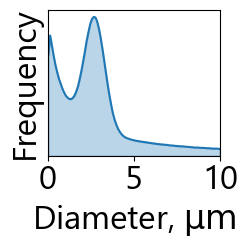

In [3]:
import numpy as np
import scipy
import matplotlib
from matplotlib import pyplot as plt


plt.rcParams.update({"font.size": 24})
plt.rcParams["font.family"] = "gadugi"
# plt.rcParams["font.serif"] = "Times New Roman"
# plt.rcParams["mathtext.fontset"] = "cm"

# matplotlib.rcParams['text.usetex'] = True
# Optional: Use a package for upright micro symbols if needed, e.g., siunitx
# matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{siunitx}' + r'\usepackage{amsmath}'


Nt1, sig_g1, mean_g1, Nt2, sig2, mean2, Nt3, sig_g3, mean_g3 = (
    122,
    1.90,
    0.30,
    54,
    0.59,
    2.73,
    48,
    1.26,
    7.28,
)


diams_t1 = np.random.lognormal(np.exp(mean_g1), sig_g1, Nt1 * 50_000)
diams_t2 = np.random.normal(mean2, sig2, Nt2 * 50_000)
diams_t3 = np.random.lognormal(np.exp(mean_g3), sig_g3, Nt3 * 50_000)
diams = np.concat([diams_t1, diams_t2, diams_t3])
bin_edges = np.linspace(0, 10, 100)
# bin_edges = np.logspace(0, 2, 100)
fig, ax = plt.subplots(figsize=[3, 3])
H = np.histogram(diams, bins=bin_edges)[0]
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
# ax.hist(diams, bins=bin_edges, histtype="step")
ax.plot(bin_centers, H)
ax.fill_between(bin_centers, H, color="C0", alpha=0.3)
ax.set(
    xlim=(0, 10),
    yticks=[],
    xticks=[0, 5, 10],
    xlabel="Diameter, $\\mathrm{\\mu m}$",
    ylabel="Frequency",
)
ax.set_ybound(lower=0)
plt.tight_layout()

fig.savefig("venus-psd.pdf", transparent=True)